# ICE STORE — Identification of Video Game Success Patterns

> **Note:** Ice Store is a fictional institution created exclusively for academic and portfolio purposes. This notebook was developed as part of a Data Science training program and is intended solely to demonstrate technical skills in data analysis and statistical modeling.

---

## Contents
1. [Introduction and Project Objective](#1.-Introduction-and-Project-Objective)
2. [Data Dictionary](#2.-Data-Dictionary)
3. [Environment Initialization](#3.-Environment-Initialization)
4. [Data Preprocessing](#4.-Data-Preprocessing)
    * 4.1. Column Normalization
    * 4.2. Handling Missing Values and Data Types
    * 4.3. Feature Engineering: Total Sales
5. [Exploratory Data Analysis (EDA)](#5.-Exploratory-Data-Analysis-(EDA))
    * 5.1. Release Volume Over Time
    * 5.2. Platform Lifecycle and Selection of Relevant Period
    * 5.3. Sales Distribution by Platform
    * 5.4. Impact of Reviews on Commercial Performance
    * 5.5. Profitability Analysis by Genre
6. [Regional User Profiles](#6.-Regional-User-Profiles)
7. [Statistical Hypothesis Testing](#7.-Statistical-Hypothesis-Testing)
8. [General Conclusion](#8.-General-Conclusion)

---

## 1. Introduction and Project Objective
The objective of this analysis is to identify patterns that determine whether a video game succeeds in the global market. By utilizing historical data from 2016, the study aims to forecast trends for 2017, allowing for optimized advertising resource allocation. The project encompasses data cleaning, exploratory analysis, regional profiling, and hypothesis testing.

## 2. Data Dictionary
- **Name**: Game title.
- **Platform**: Hardware system.
- **Year_of_Release**: Launch year.
- **Genre**: Game category.
- **NA_sales**: North American sales (USD millions).
- **EU_sales**: European sales (USD millions).
- **JP_sales**: Japanese sales (USD millions).
- **Other_sales**: Sales in other regions (USD millions).
- **Critic_Score**: Aggregate score from professionals (Max 100).
- **User_Score**: Aggregate score from users (Max 10).
- **Rating**: ESRB age rating.

## 3. Environment Initialization
The required libraries for data manipulation, statistical analysis, and visualization are imported below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Dataset loading
try:
    df = pd.read_csv('../data/games.csv')
    print("Dataset successfully loaded.")
except FileNotFoundError:
    print("Error: Dataset file not found.")

# Initial overview
df.info()
display(df.head())

Dataset successfully loaded.
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## 4. Data Preprocessing
To ensure analytical integrity, the raw data undergoes normalization. This includes converting column names to lowercase, transforming data types for mathematical operations, and handling "TBD" (To Be Determined) values in the user score column, which are functionally equivalent to null values.

In [2]:
# 4.1. Column Normalization
df.columns = df.columns.str.lower()

# 4.2. Handling Missing Values and Data Types
# Converting user_score: 'tbd' becomes NaN, then converted to float
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Converting year_of_release to Int64 to preserve integrity while allowing nulls
df['year_of_release'] = df['year_of_release'].astype('Int64')

# 4.3. Feature Engineering: Total Sales
# Aggregating sales from all regions into a single metric
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

print("Preprocessing complete. Final structure:")
df.info()

Preprocessing complete. Final structure:
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
 11  total_sales      16715 non-null  float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 1.5 MB


## 5. Exploratory Data Analysis (EDA)

### 5.1. Release Volume Over Time
Analysis of game releases per year helps determine the significance of historical periods.

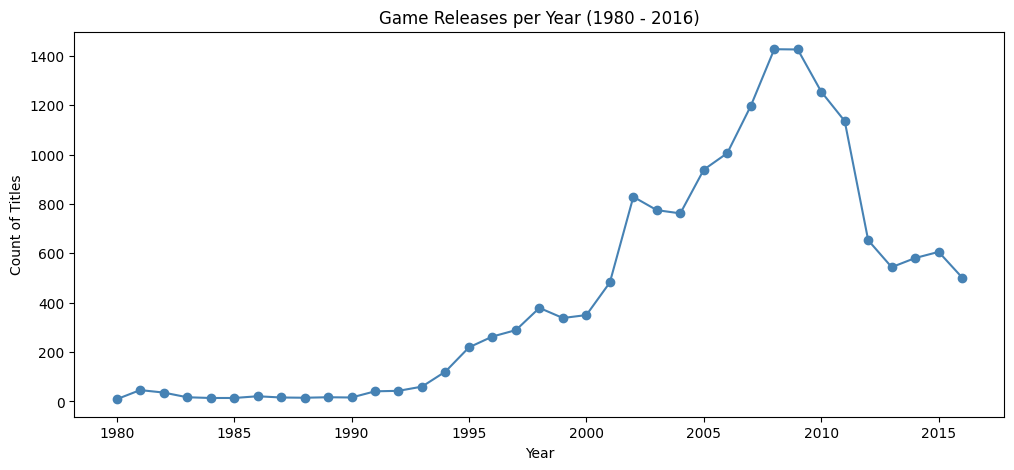

In [3]:
releases_by_year = df.groupby('year_of_release')['name'].count()

plt.figure(figsize=(12, 5))
releases_by_year.plot(kind='line', marker='o', color='steelblue')
plt.title('Game Releases per Year (1980 - 2016)')
plt.xlabel('Year')
plt.ylabel('Count of Titles')
plt.show()

### 5.2. Platform Lifecycle and Selection of Relevant Period
Industry data suggests a hardware lifecycle of 7-10 years. For a robust 2017 forecast, only data from **2014 onwards** is analyzed to ensure compatibility with current market dynamics (e.g., PS4, Xbox One).

/var/folders/3r/ttvhc73n217c_xlvgz9zzrlw0000gn/T/ipykernel_61745/1722631453.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='viridis')


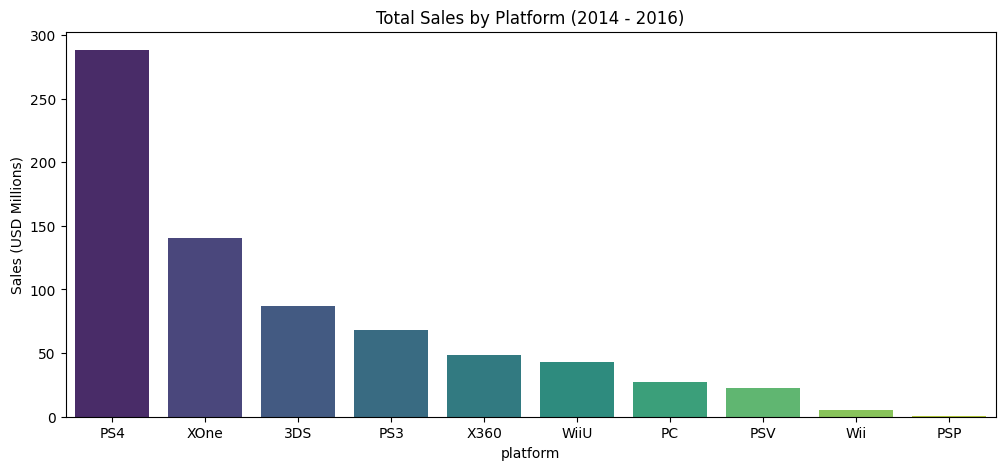

In [4]:
# Filtering for the relevant period (2014 - 2016)
df_filtered = df[df['year_of_release'] >= 2014].copy()

platform_sales = df_filtered.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='viridis')
plt.title('Total Sales by Platform (2014 - 2016)')
plt.ylabel('Sales (USD Millions)')
plt.show()

### 5.3. Sales Distribution by Platform
A boxplot analysis is utilized to understand the dispersion of global sales and identify the median performance of the most relevant platforms.

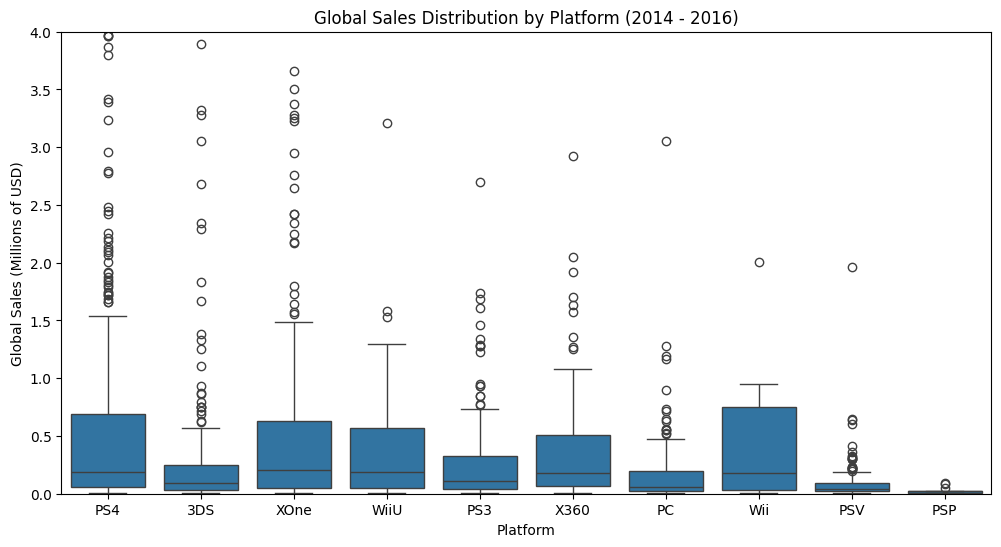

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=df_filtered)
plt.title('Global Sales Distribution by Platform (2014 - 2016)')
plt.xlabel('Platform')
plt.ylabel('Global Sales (Millions of USD)')
plt.ylim(0, 4) # Limiting y-axis to focus on the interquartile range
plt.show()

### 5.4. Impact of Reviews on Commercial Performance
Examining the correlation between professional scores (Critic Score), user ratings (User Score), and sales volume, using the market-leading PS4 as a benchmark.

Correlation for PS4:
 critic_score    0.401903
user_score     -0.043186
total_sales     1.000000
Name: total_sales, dtype: float64


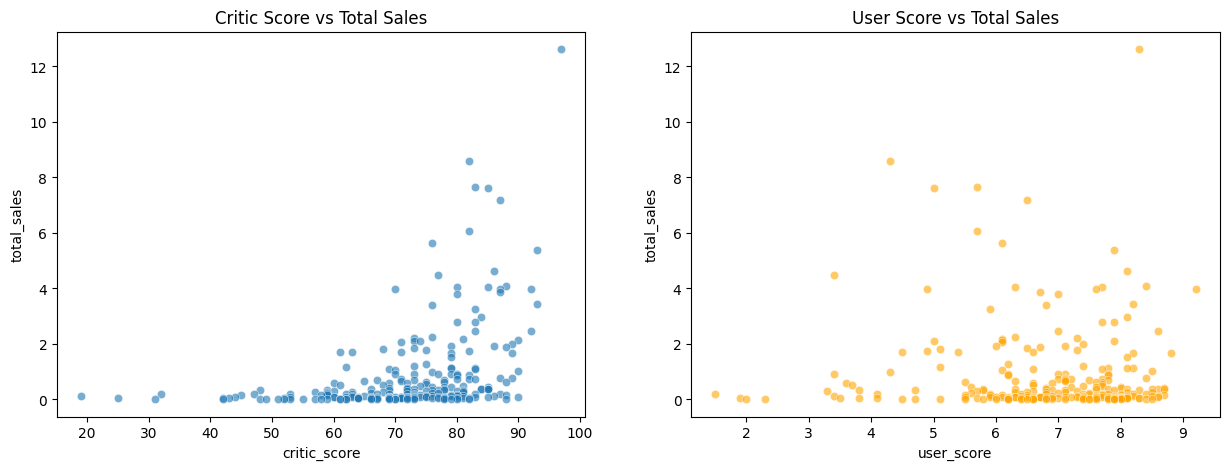

In [6]:
ps4_data = df_filtered[df_filtered['platform'] == 'PS4'].dropna(subset=['critic_score', 'user_score'])

# Correlation Analysis
correlation = ps4_data[['critic_score', 'user_score', 'total_sales']].corr()
print("Correlation for PS4:\n", correlation['total_sales'])

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=ps4_data, x='critic_score', y='total_sales', ax=ax[0], alpha=0.6)
ax[0].set_title('Critic Score vs Total Sales')

sns.scatterplot(data=ps4_data, x='user_score', y='total_sales', ax=ax[1], color='orange', alpha=0.6)
ax[1].set_title('User Score vs Total Sales')
plt.show()

### 5.5. Profitability Analysis by Genre
Evaluating the median sales by genre to identify which categories offer the most consistent financial returns globally.

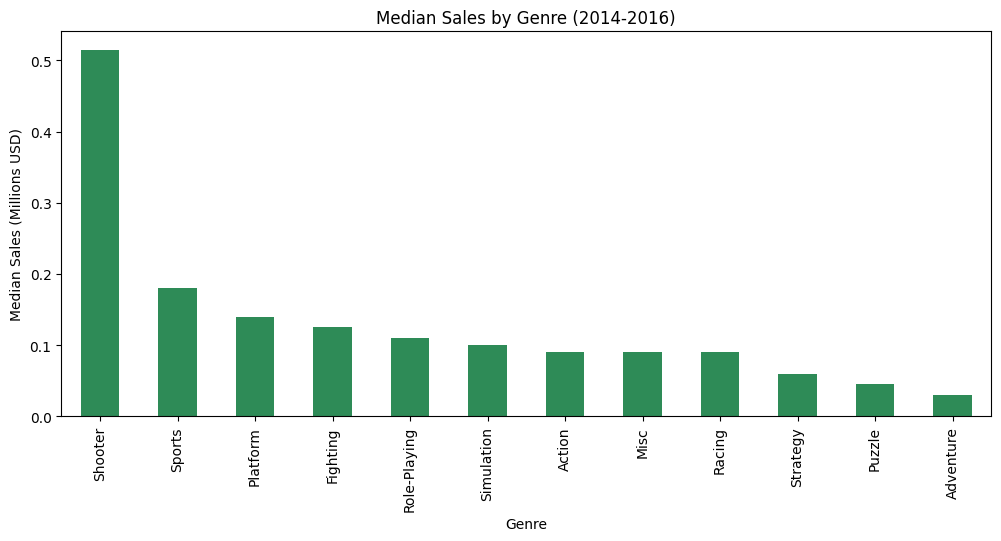

In [7]:
genre_sales = df_filtered.groupby('genre')['total_sales'].median().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
genre_sales.plot(kind='bar', color='seagreen')
plt.title('Median Sales by Genre (2014-2016)')
plt.xlabel('Genre')
plt.ylabel('Median Sales (Millions USD)')
plt.show()

## 6. Regional User Profiles
A comparative market analysis across North America (NA), Europe (EU), and Japan (JP) to highlight geographical preferences regarding platforms, genres, and ESRB ratings.

In [8]:
regions = ['na_sales', 'eu_sales', 'jp_sales']

for region in regions:
    print(f"\n{'='*40}")
    print(f"MARKET PROFILE: {region.upper()}")
    print(f"{'='*40}")
    
    print("\nTop 5 Platforms:")
    display(df_filtered.groupby('platform')[region].sum().sort_values(ascending=False).head(5))
    
    print("\nTop 5 Genres:")
    display(df_filtered.groupby('genre')[region].sum().sort_values(ascending=False).head(5))
    
    print("\nSales by ESRB Rating:")
    display(df_filtered.groupby('rating')[region].sum().sort_values(ascending=False))


MARKET PROFILE: NA_SALES

Top 5 Platforms:


platform
PS4     98.61
XOne    81.27
X360    28.30
3DS     22.64
PS3     22.05
Name: na_sales, dtype: float64


Top 5 Genres:


genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64


Sales by ESRB Rating:


...

platform
3DS     44.24
PS4     15.02
PSV     14.54
PS3     11.22
WiiU     7.31
Name: jp_sales, dtype: float64


Top 5 Genres:


genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64


Sales by ESRB Rating:


rating
T       14.78
E        8.94
M        8.01
E10+     4.46
Name: jp_sales, dtype: float64

## 7. Statistical Hypothesis Testing
Two independent T-tests are conducted to assess user rating behaviors. The standard significance level ($\alpha$) is set to 0.05.

**Hypothesis 1 (Platforms)**: 
- H0: Average user ratings for Xbox One and PC are the same.
- H1: Average user ratings for Xbox One and PC are different.

**Hypothesis 2 (Genres)**:
- H0: Average user ratings for Action and Sports genres are the same.
- H1: Average user ratings for Action and Sports genres are different.

In [9]:
alpha = 0.05

# T-Test 1: Platforms (Xbox One vs PC)
xone_scores = df_filtered[df_filtered['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_filtered[df_filtered['platform'] == 'PC']['user_score'].dropna()

t_stat_1, p_value_1 = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)
print(f"Hypothesis 1 (Platforms) P-Value: {p_value_1:.4f}")
if p_value_1 < alpha:
    print("Result: Reject H0. Ratings are significantly different.")
else:
    print("Result: Cannot reject H0. Ratings are statistically similar.")

print("-" * 30)

# T-Test 2: Genres (Action vs Sports)
action_scores = df_filtered[df_filtered['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_filtered[df_filtered['genre'] == 'Sports']['user_score'].dropna()

t_stat_2, p_value_2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f"Hypothesis 2 (Genres) P-Value: {p_value_2:.4f}")
if p_value_2 < alpha:
    print("Result: Reject H0. Ratings are significantly different.")
else:
    print("Result: Cannot reject H0. Ratings are statistically similar.")

Hypothesis 1 (Platforms) P-Value: 0.1160
Result: Cannot reject H0. Ratings are statistically similar.
------------------------------
Hypothesis 2 (Genres) P-Value: 0.0000
Result: Reject H0. Ratings are significantly different.


## 8. General Conclusion

The extensive data analysis of the 2014-2016 period provides robust, data-driven guidelines for the Ice Store's 2017 strategic planning:

1.  **Platform Dominance**: The global market is firmly anchored by the 8th generation of consoles. The **PS4** and **Xbox One** represent the highest volume of sales and the most active consumer bases. Western advertising budgets should be heavily weighted towards these ecosystems.
2.  **Regional Market Segmentation**: Consumer behavior is highly geographically dependent. 
    * **North America & Europe**: Display highly synchronized behaviors, favoring high-action and competitive genres (**Shooter, Action, Sports**). Games rated **'M' (Mature)** dominate revenue in these regions, confirming that adult audiences are the primary financial drivers in the West.
    * **Japan**: The Japanese market behaves entirely differently, favoring handheld mobility (**Nintendo 3DS**) and the **Role-Playing (RPG)** genre. Western-centric ESRB ratings have less correlation with success here.
3.  **Drivers of Commercial Success**: Statistical evaluation of scoring systems reveals that **Critic Scores** exhibit a moderate positive correlation with total sales. High critical acclaim is a reliable indicator of potential commercial success. Conversely, User Scores show negligible correlation with sales volume, suggesting that marketing campaigns should leverage professional accolades rather than community ratings.
4.  **Genre Profitability**: While Action games have a massive volume of releases, **Shooter** games demonstrate the highest *median* sales, indicating a consistently higher return on investment per title released.

**Final Recommendation:** To maximize profitability in 2017, the Ice Store must adopt a dual strategy: acquiring inventory for highly anticipated, critically acclaimed Shooter/Action titles rated 'M' for the Western markets (PS4/XOne), while curating a specialized RPG catalog for portable consoles specifically targeted at the Japanese demographic.